In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
import os

print(os.listdir())

['.config', 'train.csv', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Fill Age with Mean

df["Age"].fillna(df["Age"].mean(), inplace=True)

# Fill Embarked with Mode

df["Embarked"].fillna(
    df["Embarked"].mode()[0],
    inplace=True
)

# Drop Cabin Column

df.drop("Cabin", axis=1, inplace=True)

/tmp/ipykernel_16010/855210371.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
/tmp/ipykernel_16010/855210371.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,30,50,80],
    labels=[
        "Child",
        "Teen",
        "YoungAdult",
        "Adult",
        "Senior"
    ]
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,YoungAdult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,YoungAdult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Adult


In [16]:
age_survival = (
    df.groupby("AgeGroup")
      ["Survived"]
      .mean()
)

print(age_survival)

AgeGroup
Child         0.579710
Teen          0.428571
YoungAdult    0.331096
Adult         0.423237
Senior        0.343750
Name: Survived, dtype: float64


/tmp/ipykernel_16010/1555097698.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")


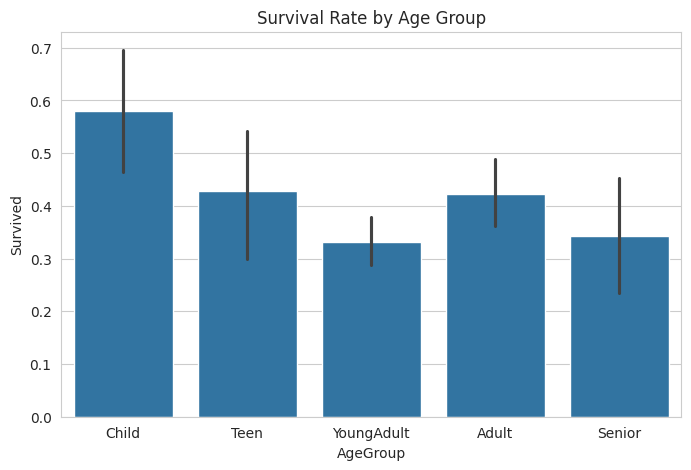

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="AgeGroup",
    y="Survived",
    data=df
)

plt.title("Survival Rate by Age Group")

plt.show()

In [18]:
port_survival = (
    df.groupby("Embarked")
      ["Survived"]
      .mean()
)

print(port_survival)

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


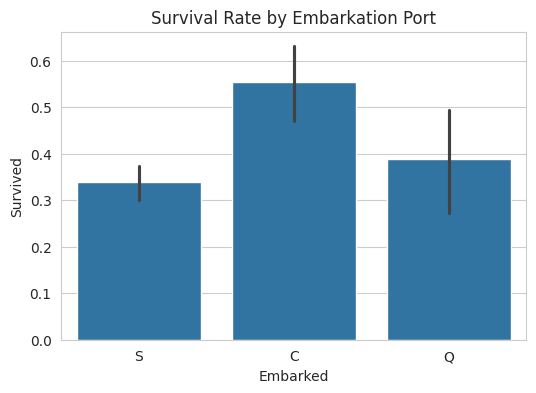

In [19]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Embarked",
    y="Survived",
    data=df
)

plt.title("Survival Rate by Embarkation Port")

plt.show()

In [20]:
df["FamilySize"] = (
    df["SibSp"] +
    df["Parch"]
)

df[
    ["SibSp",
     "Parch",
     "FamilySize"]
].head()

,SibSp,Parch,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


In [21]:
family_survival = (
    df.groupby("FamilySize")
      ["Survived"]
      .mean()
)

print(family_survival)

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


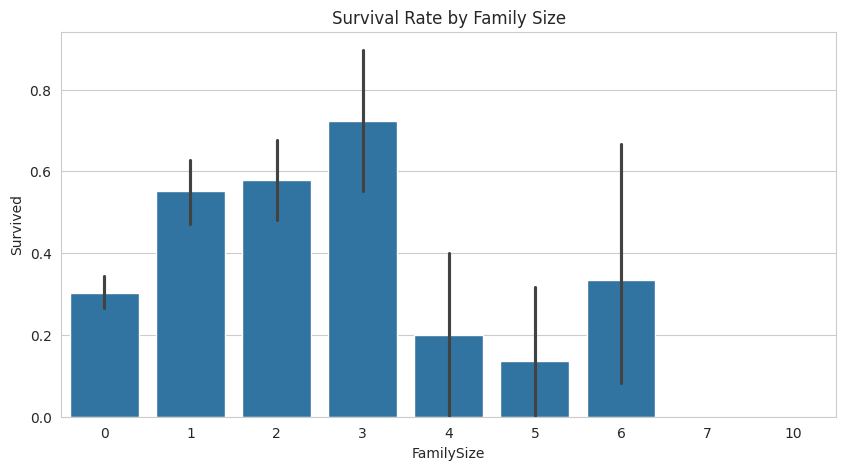

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="FamilySize",
    y="Survived",
    data=df
)

plt.title("Survival Rate by Family Size")

plt.show()

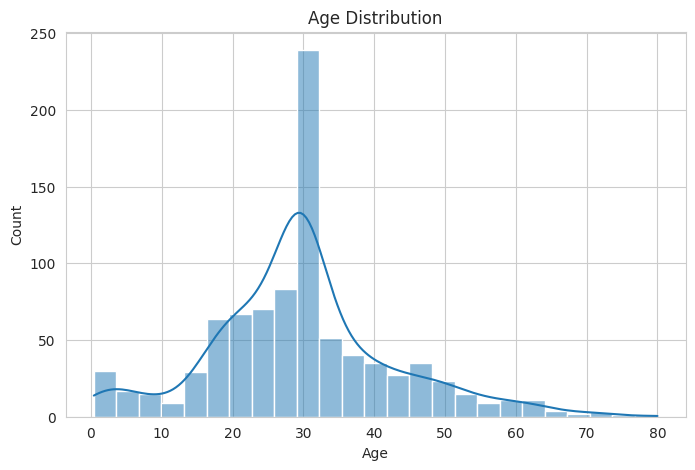

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=25,
    kde=True
)

plt.title("Age Distribution")

plt.show()

In [24]:
heatmap_df = df.copy()

heatmap_df["Sex"] = heatmap_df["Sex"].map(
    {"male":0,"female":1}
)

heatmap_df["Embarked"] = heatmap_df["Embarked"].map(
    {"S":0,"C":1,"Q":2}
)

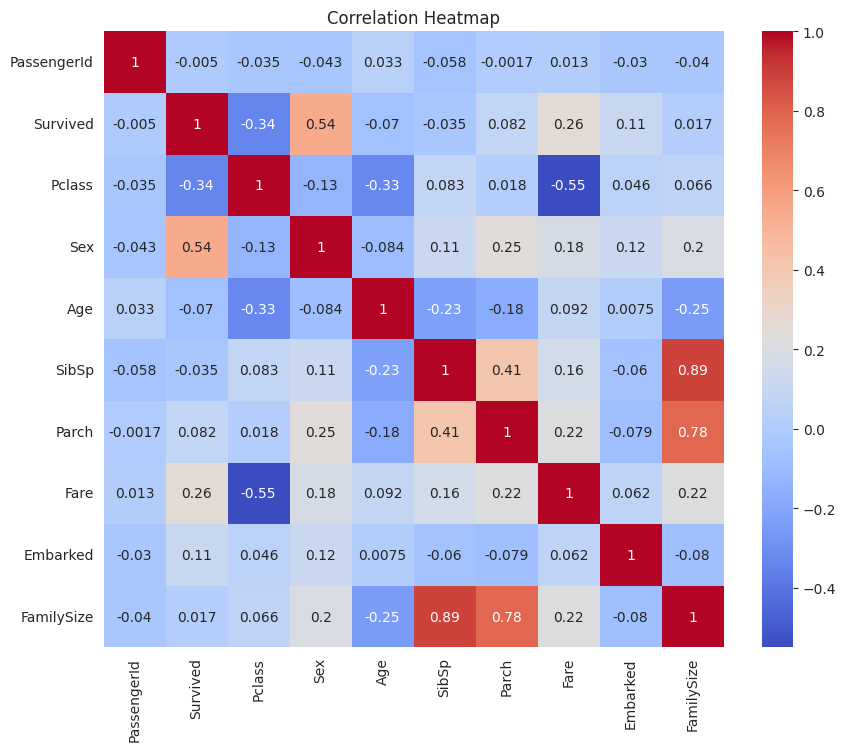

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_df.corr(
        numeric_only=True
    ),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

# Conclusion

1. Missing values were successfully handled using mean and mode imputation.

2. Age groups showed different survival rates.

3. Embarkation ports influenced passenger survival.

4. Family size had a noticeable impact on survival.

5. Most passengers were between 20 and 40 years old.

6. Correlation analysis revealed important relationships among variables.

7. EDA helped uncover meaningful insights from the Titanic dataset.